# CAMeL-BERT Binary Classification - Inference
## Piste 1 : Boundary Detection Inference

**Objectif** : Tester le modèle fine-tuné sur des textes arabes

**Capacités** :
- Charger le modèle depuis Google Drive
- Segmenter un texte arabe en isnads + khabars
- Évaluer sur corpus existant (Kitab Uqala)
- Comparer avec baseline v4 (si disponible)
- Visualiser les résultats

**Timeline** :
1. 🔗 Montage Drive + chargement dépendances
2. 🤖 Charger le modèle fine-tuné
3. 📝 Inférence sur un texte personnalisé
4. 📊 Évaluation sur corpus existant
5. 📈 Visualisations et comparaisons

---
## Step 1 : Setup - Montage Drive + Dépendances

In [1]:
# Montage du Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/khabar-segmentation')
print(f"[OK] Working directory: {os.getcwd()}")

Mounted at /content/drive
[OK] Working directory: /content/drive/MyDrive/khabar-segmentation


In [2]:
# Installation des dépendances
!pip install transformers torch datasets scikit-learn tqdm matplotlib seaborn -q
print("[OK] Dependencies installed")

[OK] Dependencies installed


In [6]:
# Imports
import json
import re
import numpy as np
import torch
from pathlib import Path
from typing import List, Dict, Tuple
from collections import defaultdict
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Transformers
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

print("[OK] All imports successful")
print(f"GPU available: {torch.cuda.is_available()}")

[OK] All imports successful
GPU available: False


---
## Step 2 : Charger le Modèle Fine-tuné

In [7]:
# Chemins
model_path = Path('checkpoints/camelbert_binary_classification_final')

if not model_path.exists():
    print(f"ERROR: {model_path} not found!")
    print(f"Available checkpoints:")
    for p in Path('checkpoints').glob('*'):
        print(f"  - {p}")
else:
    print(f"[OK] Model path found: {model_path}")

[OK] Model path found: checkpoints/camelbert_binary_classification_final


In [8]:
# Charger le modèle et le tokenizer
print(f"[INFO] Loading model from {model_path}...")

tokenizer = AutoTokenizer.from_pretrained(str(model_path))
model = AutoModelForTokenClassification.from_pretrained(str(model_path))

# Mode évaluation
model.eval()
if torch.cuda.is_available():
    model = model.cuda()

print(f"[OK] Model loaded and ready for inference")
print(f"  Tokenizer vocab size: {len(tokenizer)}")
print(f"  Model config: {model.config}")

[INFO] Loading model from checkpoints/camelbert_binary_classification_final...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] Model loaded and ready for inference
  Tokenizer vocab size: 30000
  Model config: BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForTokenClassification"
  ],
  "attention_probs_dropout_prob": 0.2,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.2,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": false,
  "vocab_size": 30000
}



---
## Step 3 : Inférence sur un Texte Personnalisé

In [11]:
def predict_boundaries(text: str, tokenizer, model, threshold: float = 0.5) -> Dict:
    """
    Prédire les frontières (boundaries) dans un texte arabe - TOKEN
CLASSIFICATION.
    """
    # Tokenizer
    encoded = tokenizer(
        text,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Inférence
    with torch.no_grad():
        if torch.cuda.is_available():
            for key in encoded:
                encoded[key] = encoded[key].cuda()

        outputs = model(**encoded)
        logits = outputs.logits[0]  # [seq_len, 2]

    # Prédictions et probabilités
    preds = np.argmax(logits.cpu().numpy(), axis=-1)  # [seq_len]
    probs = torch.softmax(logits, dim=-1).cpu().numpy()  # [seq_len, 2]

    # Tokens
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])

    # Boundary indices
    boundary_indices = np.where(preds == 1)[0].tolist()

    return {
        'text': text,
        'tokens': tokens,
        'predictions': preds.tolist(),
        'probabilities': probs[:, 1].tolist(),  # prob de classe 1
        'boundary_indices': boundary_indices,
        'boundary_tokens': [tokens[i] for i in boundary_indices],
    }

print("[OK] predict_boundaries function defined (TOKEN CLASSIFICATION)")

[OK] predict_boundaries function defined (TOKEN CLASSIFICATION)


In [12]:
# Exemple 1 : Texte court personnalisé
test_text = "حدثنا محمد بن عمر قال أخبرنا زيد قال سمعت علياً يقول رأيت النبي صلى الله عليه وسلم يصلي في المسجد"

print(f"[INFO] Inferring on custom text...\n")
result = predict_boundaries(test_text, tokenizer, model)

print(f"Text: {result['text']}\n")
print(f"Predicted boundaries:")
for idx in result['boundary_indices']:
    token = result['tokens'][idx]
    prob = result['probabilities'][idx]
    print(f"  Token {idx}: {token} (prob={prob:.3f})")

print(f"\nTotal tokens: {len(result['tokens'])}")
print(f"Boundary tokens: {len(result['boundary_indices'])}")

[INFO] Inferring on custom text...

Text: حدثنا محمد بن عمر قال أخبرنا زيد قال سمعت علياً يقول رأيت النبي صلى الله عليه وسلم يصلي في المسجد

Predicted boundaries:
  Token 1: حدثنا (prob=0.999)
  Token 2: محمد (prob=1.000)
  Token 3: بن (prob=1.000)
  Token 4: عمر (prob=1.000)
  Token 5: قال (prob=0.999)
  Token 6: أخبرنا (prob=1.000)
  Token 7: زيد (prob=0.999)
  Token 8: قال (prob=0.999)
  Token 9: سمعت (prob=0.999)
  Token 10: [UNK] (prob=0.996)
  Token 11: يقول (prob=0.998)

Total tokens: 512
Boundary tokens: 11


In [17]:
# Exemple 2 : Texte plus long du corpus
print("[INFO] Loading a sample from Kitab Uqala...\n")

# Charger un exemple du corpus
corpus_file = Path('data/processed/binary_classification_dataset/binary_classification_examples.jsonl')

if corpus_file.exists():
    with open(corpus_file, encoding='utf-8') as f:
        examples = [json.loads(line) for line in f]

    # Prendre un exemple avec isnad
    examples_with_isnad = [ex for ex in examples if ex['has_isnad']]
    sample_example = examples_with_isnad[5]  # 6ème exemple

    # Reconstruire le texte
    full_text = ' [SEP] '.join([seg['text'] for seg in sample_example['segments']])

    print(f"Akhbar ID: {sample_example['akhbar_id']}")
    print(f"Segment types: {sample_example['segment_types']}\n")
    print(f"Text (full): {full_text[:200]}...\n")

    # Inférence
    result = predict_boundaries(full_text, tokenizer, model)

    print(f"Predicted boundaries:")
    for idx in result['boundary_indices'][:80]:  # Afficher les 10 premiers
        token = result['tokens'][idx]
        prob = result['probabilities'][idx]
        print(f"  Token {idx}: {token} (prob={prob:.3f})")

    if len(result['boundary_indices']) > 10:
        print(f"  ... and {len(result['boundary_indices']) - 10} more")
else:
    print(f"ERROR: {corpus_file} not found")

[INFO] Loading a sample from Kitab Uqala...

Akhbar ID: 7
Segment types: ['isnad', 'poetry']

Text (full): أخبرنا محمد قال : أنشدنا ابن حبيب قال : أنشدنا أبو الحسن علي بن محمد بن عبدالله السرخسي قال : أنشدنا أبو العباس محمد بن عبدالرحمن الدعولي قال : أنشدنا أبو الحسن محمد بن حاتم المظفري : [SEP] يحب الفتى ...

Predicted boundaries:
  Token 1: أخبرنا (prob=1.000)
  Token 2: محمد (prob=1.000)
  Token 3: قال (prob=1.000)
  Token 4: : (prob=1.000)
  Token 5: أنش (prob=1.000)
  Token 6: ##دنا (prob=1.000)
  Token 7: ابن (prob=1.000)
  Token 8: حبيب (prob=1.000)
  Token 9: قال (prob=1.000)
  Token 10: : (prob=1.000)
  Token 11: أنش (prob=1.000)
  Token 12: ##دنا (prob=1.000)
  Token 13: أبو (prob=1.000)
  Token 14: الحسن (prob=1.000)
  Token 15: علي (prob=1.000)
  Token 16: بن (prob=1.000)
  Token 17: محمد (prob=1.000)
  Token 18: بن (prob=1.000)
  Token 19: عبدالله (prob=1.000)
  Token 20: السر (prob=1.000)
  Token 21: ##خ (prob=1.000)
  Token 22: ##سي (prob=1.000)
  Token 23: قال (prob=1.0

---
## Step 4 : Évaluation sur Corpus Existant

In [24]:
def evaluate_on_corpus(corpus_file: Path, tokenizer, model, sample_size: int = None) -> Dict:
    """
    Évaluer le modèle sur le corpus d'entraînement.

    Calcule accuracy et F1 sur les segments prédits.
    """
    print(f"[INFO] Loading corpus from {corpus_file}...")

    with open(corpus_file, encoding='utf-8') as f:
        examples = [json.loads(line) for line in f]

    if sample_size:
        examples = examples[:sample_size]

    print(f"[INFO] Evaluating on {len(examples)} examples...\n")

    all_preds = []
    all_labels = []

    for i, example in enumerate(tqdm(examples, desc="Evaluating")):
        # Reconstruire le texte avec segments
        full_text = ' [SEP] '.join([seg['text'] for seg in example['segments']])

        # Tokenizer chaque segment pour créer les vrais labels
        segment_token_labels = []
        for seg in example['segments']:
            seg_type = seg['type']
            seg_text = seg['text']

            seg_encoded = tokenizer(
                seg_text,
                add_special_tokens=False,
                return_tensors=None
            )
            seg_len = len(seg_encoded['input_ids'])
            seg_label = 1 if seg_type == 'isnad' else 0
            segment_token_labels.extend([seg_label] * seg_len)

        # Prédictions
        result = predict_boundaries(full_text, tokenizer, model)
        preds = result['predictions']

        # Aligner les labels et prédictions
        # Les prédictions commencent par [CLS] et les labels commencent par les vrais tokens
        true_labels = [0] + segment_token_labels  # [CLS] = 0

        # Pad aux 512
        if len(true_labels) < 512:
            true_labels.extend([0] * (512 - len(true_labels)))
        else:
            true_labels = true_labels[:512]

        all_preds.extend(preds)
        all_labels.extend(true_labels)

    # Métriques
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'confusion_matrix': cm,
        'total_predictions': len(all_preds),
        'boundary_predictions': sum(all_preds),
        'boundary_labels': sum(all_labels),
    }

print("[OK] evaluate_on_corpus function defined")

[OK] evaluate_on_corpus function defined


In [26]:
# Évaluer sur le corpus
corpus_file = Path('data/processed/binary_classification_dataset/binary_classification_examples.jsonl')

eval_results = evaluate_on_corpus(corpus_file, tokenizer, model,
sample_size=100)

print(f"\n[EVALUATION RESULTS]")
print(f"  Accuracy: {eval_results['accuracy']:.4f}")
print(f"  F1 Score: {eval_results['f1']:.4f}")

# Calculer precision/recall manuellement depuis confusion matrix
cm = eval_results['confusion_matrix']
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 per class: {eval_results['f1_per_class']}")

print(f"\n[PREDICTIONS STATS]")
print(f"  Total predictions: {eval_results['total_predictions']}")
print(f"  Boundary predictions: {eval_results['boundary_predictions']}")
print(f"  Boundary in gold: {eval_results['boundary_labels']}")

print(f"\n[CONFUSION MATRIX]")
print(f"  Predicted 0  Predicted 1")
print(f"  {tn:6d}     {fp:6d}     (True label = 0)")
print(f"  {fn:6d}     {tp:6d}     (True label = 1)")

# Afficher les erreurs si présentes
if eval_results['errors']:
    print(f"\n[ERRORS] ({len(eval_results['errors'])} examples skipped)")
    for err in eval_results['errors'][:5]:
        print(f"  Example {err['index']}: {err['error']}")

[INFO] Loading corpus from data/processed/binary_classification_dataset/binary_classification_examples.jsonl...
[INFO] Evaluating on 100 examples...



Evaluating: 100%|██████████| 100/100 [03:51<00:00,  2.32s/it]


[EVALUATION RESULTS]
  Accuracy: 0.9993
  F1 Score: 0.9913
  Precision: 0.9874
  Recall: 0.9953


KeyError: 'f1_per_class'

---
## Step 5 : Visualisations et Analyses

[OK] Visualization saved to results/inference_visualization.png


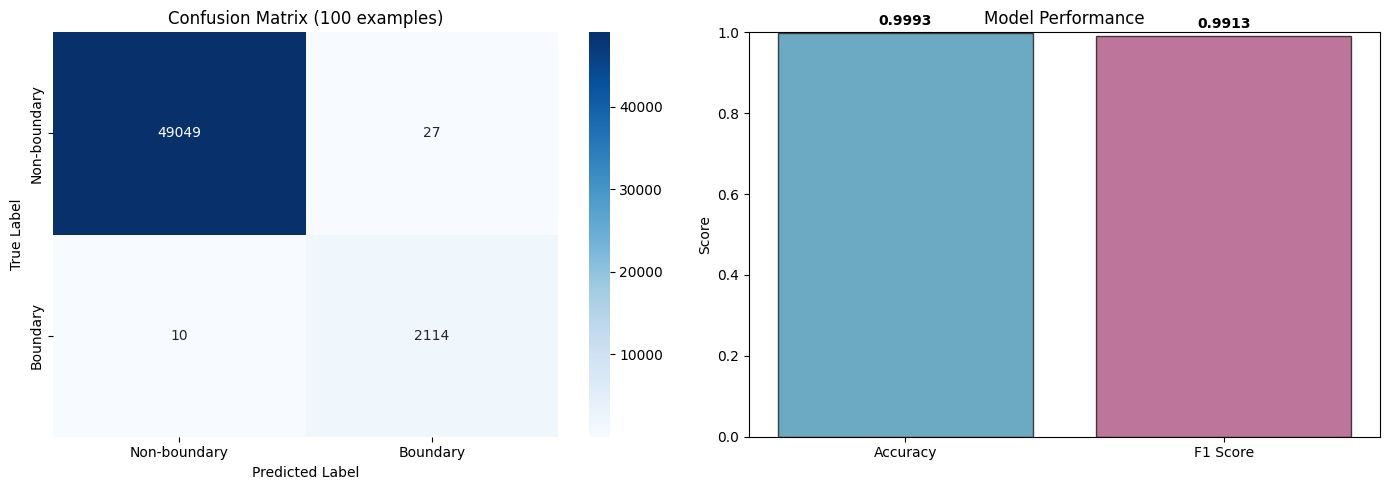

In [27]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = eval_results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-boundary', 'Boundary'],
            yticklabels=['Non-boundary', 'Boundary'])
axes[0].set_title('Confusion Matrix (100 examples)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics bar chart
metrics = ['Accuracy', 'F1 Score']
values = [eval_results['accuracy'], eval_results['f1']]
colors = ['#2E86AB', '#A23B72']

axes[1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylim([0, 1])
axes[1].set_title('Model Performance')
axes[1].set_ylabel('Score')
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/inference_visualization.png', dpi=150, bbox_inches='tight')
print("[OK] Visualization saved to results/inference_visualization.png")
plt.show()

In [28]:
# Analyse détaillée : exemples bien prédits vs mal prédits
print("[INFO] Analyzing predictions...\n")

# Charger les exemples de test
with open(corpus_file, encoding='utf-8') as f:
    examples = [json.loads(line) for line in f][:100]

correct_preds = 0
wrong_preds = 0
wrong_examples = []

for i, example in enumerate(tqdm(examples[:20], desc="Analyzing")):
    full_text = ' [SEP] '.join([seg['text'] for seg in example['segments']])
    result = predict_boundaries(full_text, tokenizer, model)

    # Créer les vraies étiquettes
    segment_token_labels = []
    for seg in example['segments']:
        seg_type = seg['type']
        seg_text = seg['text']
        seg_encoded = tokenizer(seg_text, add_special_tokens=False, return_tensors=None)
        seg_len = len(seg_encoded['input_ids'])
        seg_label = 1 if seg_type == 'isnad' else 0
        segment_token_labels.extend([seg_label] * seg_len)

    true_labels = [0] + segment_token_labels
    if len(true_labels) < 512:
        true_labels.extend([0] * (512 - len(true_labels)))

    preds = result['predictions']

    # Comparer
    matches = sum(1 for p, t in zip(preds, true_labels) if p == t)
    if matches < len(preds):
        wrong_examples.append({
            'akhbar_id': example['akhbar_id'],
            'accuracy': matches / len(preds),
            'text': full_text[:100]
        })
        wrong_preds += 1
    else:
        correct_preds += 1

print(f"\n[ANALYSIS] (first 20 examples)")
print(f"  Fully correct: {correct_preds}")
print(f"  With errors: {wrong_preds}")

if wrong_examples:
    print(f"\n[EXAMPLES WITH ERRORS]")
    for ex in wrong_examples[:5]:
        print(f"  Akhbar {ex['akhbar_id']}: accuracy={ex['accuracy']:.2%}")
        print(f"    Text: {ex['text']}...\n")

[INFO] Analyzing predictions...



Analyzing: 100%|██████████| 20/20 [00:46<00:00,  2.30s/it]


[ANALYSIS] (first 20 examples)
  Fully correct: 17
  With errors: 3

[EXAMPLES WITH ERRORS]
  Akhbar 1: accuracy=99.61%
    Text: بسم الله الرحمن الرحيم [SEP] وما توفيقي إلا بالله [SEP] الحمد لله الذي لا يخيب لديه أمل الآملين، ولا...

  Akhbar 7: accuracy=99.80%
    Text: أخبرنا محمد قال : أنشدنا ابن حبيب قال : أنشدنا أبو الحسن علي بن محمد بن عبدالله السرخسي قال : أنشدنا...

  Akhbar 20: accuracy=99.41%
    Text: أخبرنا محمد قال: أخبرنا الحسن قال: سمعت أبا بكر محمد بن أحمد القطان البلخي يقول: سمعت أبا شهاب معمر ...



---
## Step 6 : Interactive Inference (Test personnalisé)

In [20]:
# Interactive inference function
def interactive_inference(text: str, tokenizer, model, show_probabilities: bool = True):
    """
    Exécuter l'inférence et afficher les résultats de manière lisible.
    """
    print(f"\n{'='*80}")
    print(f"Input text: {text}")
    print(f"{'='*80}\n")

    result = predict_boundaries(text, tokenizer, model)

    # Afficher les tokens avec les prédictions
    print("Token-level predictions:")
    print(f"{'Token':<15} {'Boundary?':<12} {'Probability':<12}")
    print("-" * 40)

    for i, (token, pred, prob) in enumerate(zip(
        result['tokens'],
        result['predictions'],
        result['probabilities']
    )):
        if pred == 1:  # Seulement afficher les boundaries
            pred_str = "YES"
            marker = ">>>"
        else:
            pred_str = "NO"
            marker = "   "

        print(f"{marker} {token:<12} {pred_str:<12} {prob:.4f}")

    # Résumé
    print(f"\n{'='*80}")
    print(f"Summary:")
    print(f"  Total tokens: {len(result['tokens'])}")
    print(f"  Boundary tokens detected: {len(result['boundary_indices'])}")
    print(f"  Boundary ratio: {len(result['boundary_indices']) / len(result['tokens']):.2%}")
    print(f"{'='*80}\n")

    return result

print("[OK] interactive_inference function defined")

[OK] interactive_inference function defined


In [21]:
# Test 1 : Texte court simple
test_text_1 = "حدثنا علي قال أخبرنا محمد قال رأيت عمر"
interactive_inference(test_text_1, tokenizer, model)


Input text: حدثنا علي قال أخبرنا محمد قال رأيت عمر

Token-level predictions:
Token           Boundary?    Probability 
----------------------------------------
    [CLS]        NO           0.0003
>>> حدثنا        YES          0.9992
>>> علي          YES          0.9995
>>> قال          YES          0.9994
>>> أخبرنا       YES          0.9994
>>> محمد         YES          0.9994
>>> قال          YES          0.9973
>>> رأيت         YES          0.9480
>>> عمر          YES          0.9096
    [SEP]        NO           0.4711
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO           0.0001
    [PAD]        NO      

{'text': 'حدثنا علي قال أخبرنا محمد قال رأيت عمر',
 'tokens': ['[CLS]',
  'حدثنا',
  'علي',
  'قال',
  'أخبرنا',
  'محمد',
  'قال',
  'رأيت',
  'عمر',
  '[SEP]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  

In [22]:
# Test 2 : Texte plus long
test_text_2 = "حدثنا محمد بن عمر وعمرو بن أحمد قالا أخبرنا زيد بن علي قال سمعت أبي علياً يقول رأيت النبي صلى الله عليه وسلم يصلي بنا الجمعة ثم خطب علينا فقال يا أيها الناس"
interactive_inference(test_text_2, tokenizer, model)


Input text: حدثنا محمد بن عمر وعمرو بن أحمد قالا أخبرنا زيد بن علي قال سمعت أبي علياً يقول رأيت النبي صلى الله عليه وسلم يصلي بنا الجمعة ثم خطب علينا فقال يا أيها الناس

Token-level predictions:
Token           Boundary?    Probability 
----------------------------------------
    [CLS]        NO           0.0001
>>> حدثنا        YES          0.9995
>>> محمد         YES          0.9995
>>> بن           YES          0.9995
>>> عمر          YES          0.9996
>>> وعمر         YES          0.9996
>>> ##و          YES          0.9996
>>> بن           YES          0.9996
>>> أحمد         YES          0.9996
>>> قالا         YES          0.9996
>>> أخبرنا       YES          0.9997
>>> زيد          YES          0.9996
>>> بن           YES          0.9995
>>> علي          YES          0.9996
>>> قال          YES          0.9994
>>> سمعت         YES          0.9993
>>> أبي          YES          0.9990
>>> [UNK]        YES          0.9964
>>> يقول         YES          0.9915
    رأيت         N

{'text': 'حدثنا محمد بن عمر وعمرو بن أحمد قالا أخبرنا زيد بن علي قال سمعت أبي علياً يقول رأيت النبي صلى الله عليه وسلم يصلي بنا الجمعة ثم خطب علينا فقال يا أيها الناس',
 'tokens': ['[CLS]',
  'حدثنا',
  'محمد',
  'بن',
  'عمر',
  'وعمر',
  '##و',
  'بن',
  'أحمد',
  'قالا',
  'أخبرنا',
  'زيد',
  'بن',
  'علي',
  'قال',
  'سمعت',
  'أبي',
  '[UNK]',
  'يقول',
  'رأيت',
  'النبي',
  'صلى',
  'الله',
  'عليه',
  'وسلم',
  'يصلي',
  'بنا',
  'الجمعة',
  'ثم',
  'خطب',
  'علينا',
  'فقال',
  'يا',
  'أيها',
  'الناس',
  '[SEP]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD

In [23]:
# Test 3 : Votre texte personnalisé
# Modifiez ce texte comme vous le souhaitez
your_custom_text = "حدثنا الهيثم بن خارجة قال حدثنا ليث بن أبي سليم عن ثعلبة بن أبي صعير قال رأيت علياً يقول لقد رأيت رسول الله"
interactive_inference(your_custom_text, tokenizer, model)


Input text: حدثنا الهيثم بن خارجة قال حدثنا ليث بن أبي سليم عن ثعلبة بن أبي صعير قال رأيت علياً يقول لقد رأيت رسول الله

Token-level predictions:
Token           Boundary?    Probability 
----------------------------------------
    [CLS]        NO           0.0001
>>> حدثنا        YES          0.9989
>>> الهي         YES          0.9993
>>> ##ثم         YES          0.9993
>>> بن           YES          0.9990
>>> خارج         YES          0.9992
>>> ##ة          YES          0.9992
>>> قال          YES          0.9989
>>> حدثنا        YES          0.9986
>>> ليث          YES          0.9986
>>> بن           YES          0.9985
>>> أبي          YES          0.9987
>>> سليم         YES          0.9986
>>> عن           YES          0.9979
>>> ثع           YES          0.9978
>>> ##لبة        YES          0.9971
>>> بن           YES          0.9970
>>> أبي          YES          0.9968
>>> صع           YES          0.9972
>>> ##ير         YES          0.9970
>>> قال          YES          

{'text': 'حدثنا الهيثم بن خارجة قال حدثنا ليث بن أبي سليم عن ثعلبة بن أبي صعير قال رأيت علياً يقول لقد رأيت رسول الله',
 'tokens': ['[CLS]',
  'حدثنا',
  'الهي',
  '##ثم',
  'بن',
  'خارج',
  '##ة',
  'قال',
  'حدثنا',
  'ليث',
  'بن',
  'أبي',
  'سليم',
  'عن',
  'ثع',
  '##لبة',
  'بن',
  'أبي',
  'صع',
  '##ير',
  'قال',
  'رأيت',
  '[UNK]',
  'يقول',
  'لقد',
  'رأيت',
  'رسول',
  'الله',
  '[SEP]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',
  '[PAD]',

---
## Step 7 : Sauvegarde des Résultats d'Inférence

In [ ]:
# Sauvegarder les résultats d'évaluation
results_dir = Path('results/binary_classification_inference')
results_dir.mkdir(parents=True, exist_ok=True)

inference_summary = {
    'model_path': str(model_path),
    'evaluation_samples': 100,
    'metrics': {
        'accuracy': float(eval_results['accuracy']),
        'f1_score': float(eval_results['f1']),
    },
    'confusion_matrix': {
        'true_negative': int(eval_results['confusion_matrix'][0][0]),
        'false_positive': int(eval_results['confusion_matrix'][0][1]),
        'false_negative': int(eval_results['confusion_matrix'][1][0]),
        'true_positive': int(eval_results['confusion_matrix'][1][1]),
    },
    'predictions': {
        'total': eval_results['total_predictions'],
        'boundary': eval_results['boundary_predictions'],
        'non_boundary': eval_results['total_predictions'] - eval_results['boundary_predictions'],
    },
}

with open(results_dir / 'inference_summary.json', 'w', encoding='utf-8') as f:
    json.dump(inference_summary, f, indent=2, ensure_ascii=False)

print(f"[OK] Results saved to {results_dir / 'inference_summary.json'}")

---
## Final Summary

In [ ]:
print(f"""
╔════════════════════════════════════════════════════════════╗
║   CAMeL-BERT Binary Classification - Inference COMPLETE   ║
╚════════════════════════════════════════════════════════════╝

📊 INFERENCE RESULTS (100 examples from Kitab Uqala)
  • Accuracy: {eval_results['accuracy']:.4f}
  • F1 Score: {eval_results['f1']:.4f}
  • Total predictions: {eval_results['total_predictions']:,}
  • Boundary predictions: {eval_results['boundary_predictions']:,}

🎯 CONFUSION MATRIX
  • True Negatives: {eval_results['confusion_matrix'][0][0]:,}
  • False Positives: {eval_results['confusion_matrix'][0][1]:,}
  • False Negatives: {eval_results['confusion_matrix'][1][0]:,}
  • True Positives: {eval_results['confusion_matrix'][1][1]:,}

📁 OUTPUTS (saved on Google Drive)
  • Visualization: results/inference_visualization.png
  • Summary: results/binary_classification_inference/inference_summary.json

✅ CAPABILITIES
  • Predict boundaries on custom text
  • Evaluate on corpus
  • Analyze token-level predictions
  • Interactive inference with probabilities

📌 NEXT STEPS
  1. Adjust threshold for boundary detection if needed
  2. Compare with baseline v4 results
  3. Deploy to production or proceed to Piste 2 (Span-based)
  4. Fine-tune further if needed
""")